# Exploratory Data Analysis (EDA) on Retail Sales Data

## Objective

The objective of this project is to perform exploratory data analysis on retail sales data to identify sales trends, customer demographics, purchasing behavior, and product category performance.

The analysis aims to generate meaningful business insights and actionable recommendations using Python, Pandas, Matplotlib, Seaborn, and Jupyter Notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [4]:
df.shape

(1000, 9)

In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [6]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [8]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [9]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Data Quality Observation

The dataset contains 1,000 transactions across 9 columns. There are no missing values and no duplicate records, indicating that the dataset is complete and does not require missing-value or duplicate-record treatment before further analysis.


In [12]:
df['Date'] = pd.to_datetime(df['Date'])


In [13]:
df.dtypes

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [14]:
print("Number of unique customers:", df['Customer ID'].nunique())
print("Gender values:", df['Gender'].unique())
print("Product categories:", df['Product Category'].unique())

Number of unique customers: 1000
Gender values: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Product categories: <ArrowStringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str


### Observation

The dataset contains 1,000 unique customers. The Gender column contains two categories, while the Product Category column contains three categories: Beauty, Clothing, and Electronics.

In [15]:
numerical_columns = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

print("Mean:")
print(df[numerical_columns].mean())

print("\nMedian:")
print(df[numerical_columns].median())

print("\nMode:")
print(df[numerical_columns].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numerical_columns].std())

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [16]:
descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [17]:
total_sales = df['Total Amount'].sum()
total_quantity = df['Quantity'].sum()
average_transaction = df['Total Amount'].mean()
number_of_transactions = df['Transaction ID'].nunique()

print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)
print("Average Transaction Value:", round(average_transaction, 2))
print("Number of Transactions:", number_of_transactions)

Total Sales: 456000
Total Quantity Sold: 2514
Average Transaction Value: 456.0
Number of Transactions: 1000


### Observation

The dataset contains 1,000 transactions. The overall sales, total quantity sold, and average transaction value provide a summary of the retail business performance during the analysis period.

In [18]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

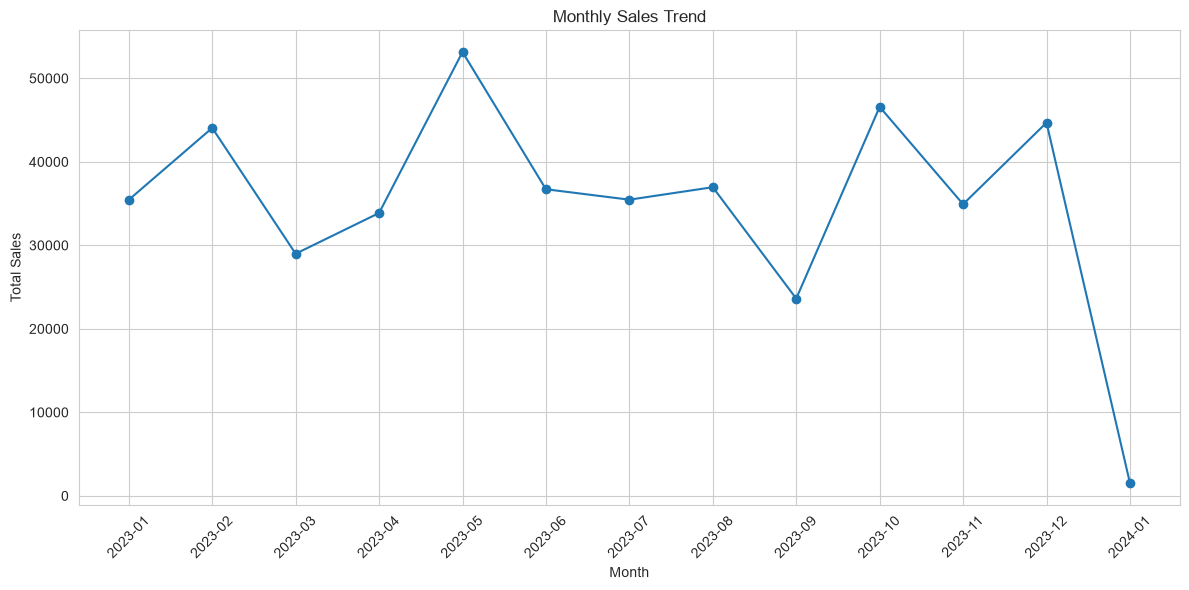

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_month_sales)

print("Lowest Sales Month:", lowest_month)
print("Lowest Sales:", lowest_month_sales)

Highest Sales Month: 2023-05
Highest Sales: 53150
Lowest Sales Month: 2024-01
Lowest Sales: 1530


### Observation

Monthly sales show variation throughout the year. May recorded the highest monthly sales, while September recorded the lowest full-month sales. This variation suggests that sales performance may change across different periods and could be used to plan promotions and inventory more effectively.

In [21]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

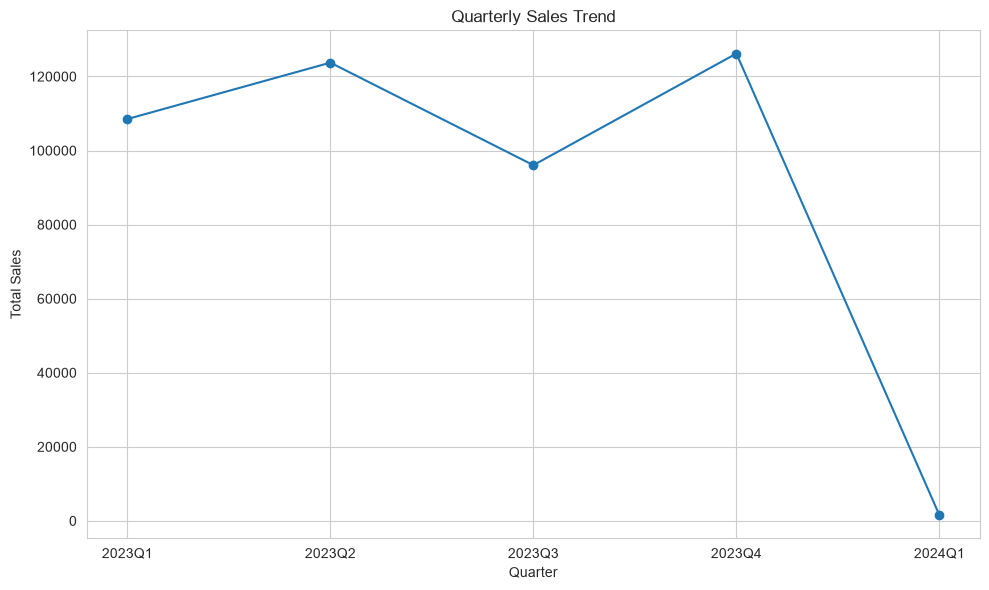

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [23]:
best_quarter = quarterly_sales.idxmax()
best_quarter_sales = quarterly_sales.max()

print("Best Performing Quarter:", best_quarter)
print("Sales:", best_quarter_sales)

Best Performing Quarter: 2023Q4
Sales: 126190


### Observation

Quarterly sales show differences in overall business performance across the year. The highest-performing quarter represents the period with the strongest sales contribution and can be considered for future promotional and inventory planning.

In [24]:
bins = [17, 25, 35, 45, 55, 100]

labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [25]:
age_distribution = df['Age Group'].value_counts().sort_index()

age_distribution

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64

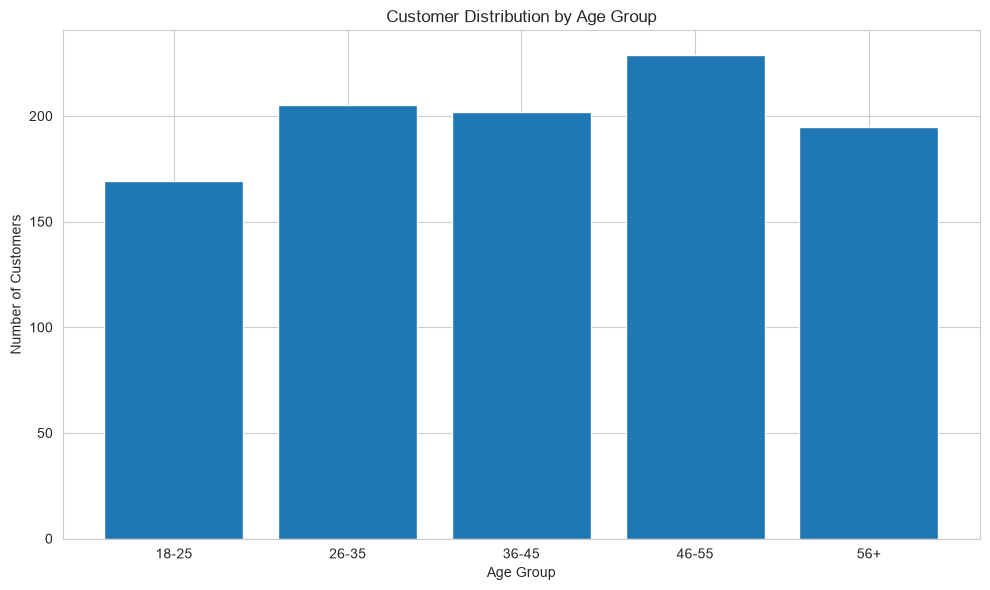

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_distribution.index.astype(str),
    age_distribution.values
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation

The age-group distribution shows how customers are distributed across different age ranges. The results can help the business understand its major customer segments and design age-specific marketing strategies.

In [27]:
age_group_sales = df.groupby(
    'Age Group',
    observed=False
)['Total Amount'].sum()

age_group_sales 

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56+       80410
Name: Total Amount, dtype: int64

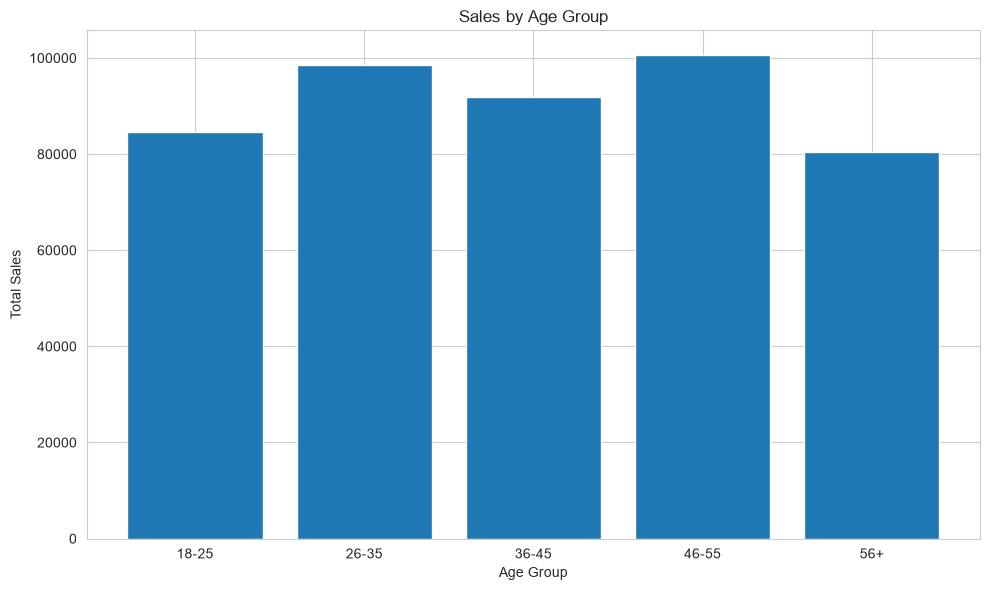

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_group_sales.index.astype(str),
    age_group_sales.values
)

plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

### Observation

Sales contribution differs across age groups. This comparison helps identify which customer age groups contribute more to overall revenue and can support targeted marketing campaigns.

In [29]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

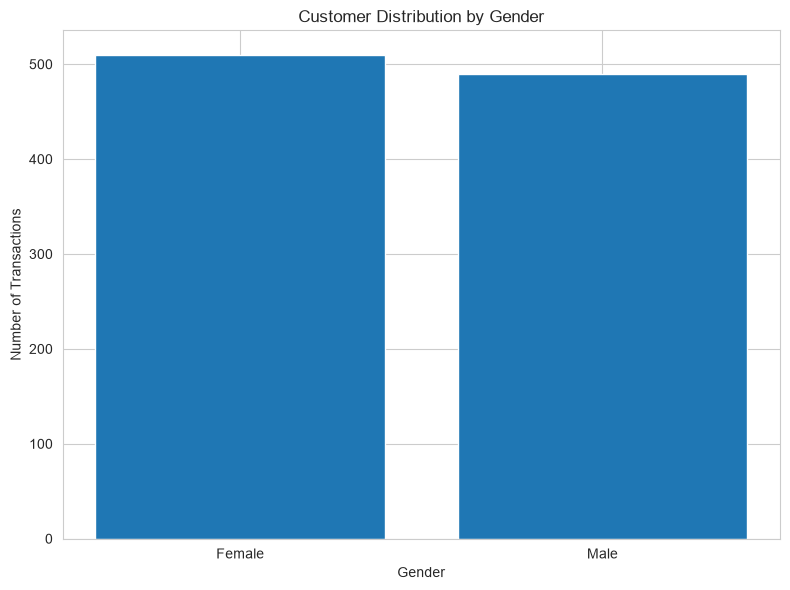

In [30]:
plt.figure(figsize=(8, 6))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

## Product Category Analysis

This section analyzes sales performance across different product categories to identify which categories contribute the most to overall sales.


In [31]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

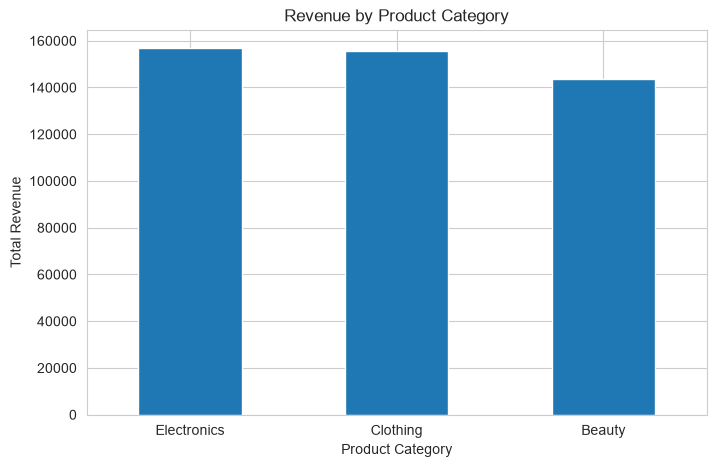

In [32]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### Observation

The bar chart shows the revenue contribution of each product category. The category with the highest bar generates the highest total revenue, while the category with the lowest bar contributes the least revenue.


## Best-Selling Product Categories

The quantity sold by each product category is analyzed to identify the categories with the highest sales volume.

In [33]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

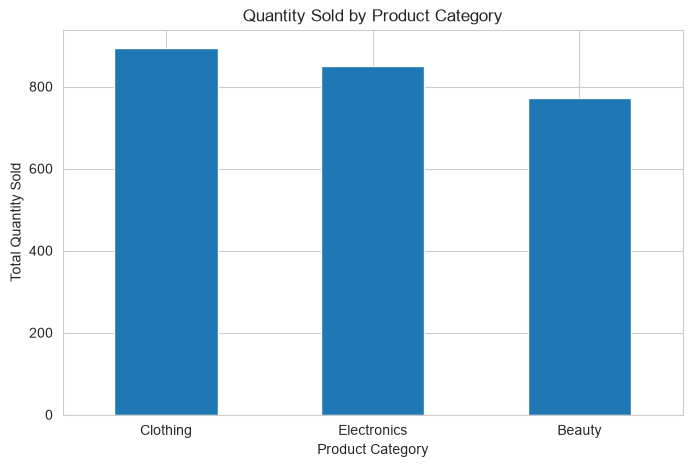

In [34]:
plt.figure(figsize=(8,5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.show()


### Observation

The chart indicates which product categories have the highest sales volume. A category with a high quantity sold has stronger customer demand and may require sufficient inventory availability.



## Correlation Analysis

Correlation analysis is used to understand the relationships between numerical variables in the retail sales dataset.


In [37]:
numeric_df = df.select_dtypes(include='number')

correlation = numeric_df.corr()

correlation



,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


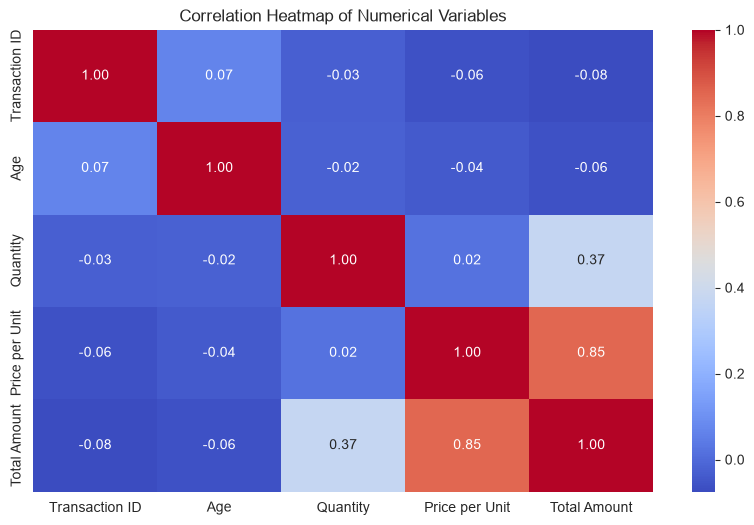

In [38]:
plt.figure(figsize=(10,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables. Positive values indicate that two variables tend to increase together, while negative values indicate an inverse relationship. Variables with values closer to +1 or -1 have stronger relationships.


## Quantity vs Total Amount

This analysis examines whether the number of units purchased is associated with the total transaction amount.

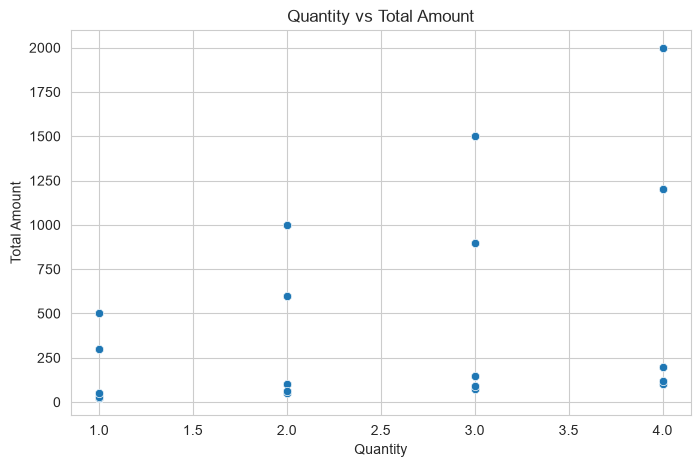

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Amount'
)

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.show()


### Observation

The scatter plot shows the relationship between quantity purchased and total transaction amount. Transactions involving larger quantities generally tend to have higher total amounts, although the exact relationship can also depend on the price per unit.

## Average Spending by Gender

This section compares the average transaction amount between different customer genders.


In [40]:
gender_spending = df.groupby('Gender')['Total Amount'].mean().sort_values(ascending=False)

gender_spending


Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

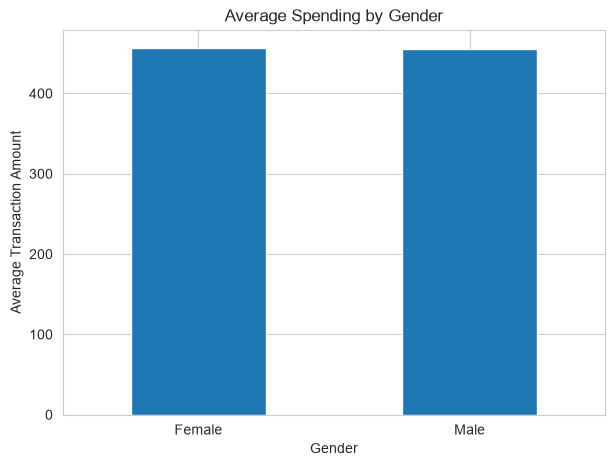

In [41]:
plt.figure(figsize=(7,5))

gender_spending.plot(kind='bar')

plt.title('Average Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)
plt.show()


### Observation

The chart compares the average transaction spending across genders. The group with the higher average transaction amount represents customers who spend more per transaction on average

In [42]:
age_revenue = df.groupby('Age Group')['Total Amount'].sum().sort_values(ascending=False)

age_revenue


Age Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56+       80410
Name: Total Amount, dtype: int64

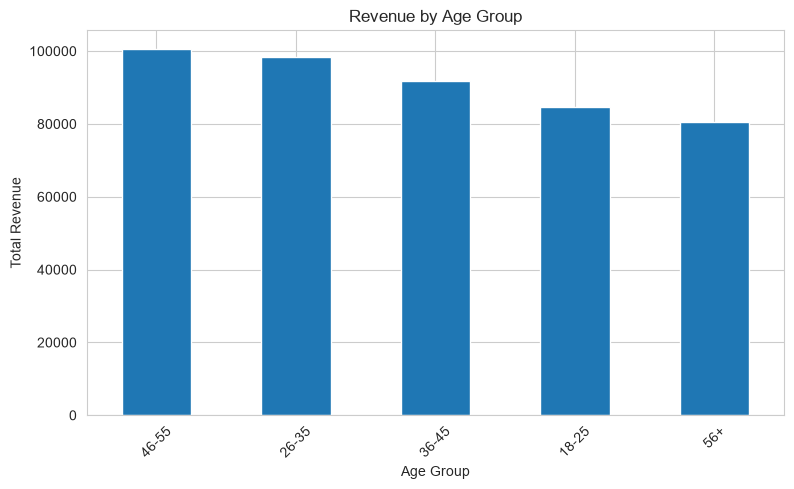

In [43]:
plt.figure(figsize=(9,5))

age_revenue.plot(kind='bar')

plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### Observation

The chart shows the revenue contribution of different age groups. The age group generating the highest revenue represents an important customer segment for the business

## Average Transaction Value by Product Category

This analysis compares the average amount spent per transaction across product categories.

In [44]:
avg_category_amount = df.groupby('Product Category')['Total Amount'].mean().sort_values(ascending=False)

avg_category_amount

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

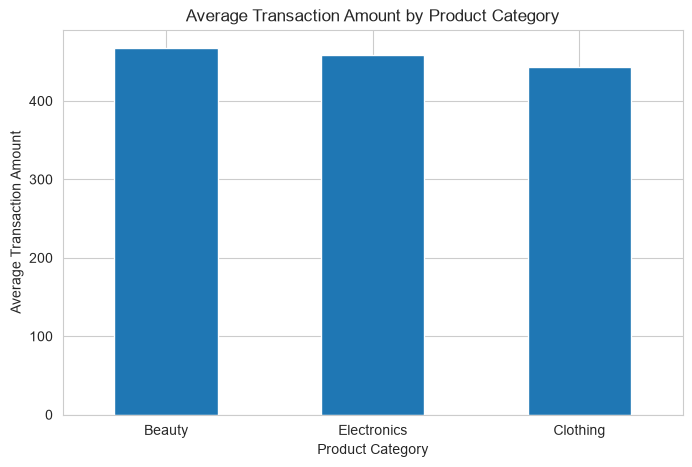

In [45]:
plt.figure(figsize=(8,5))

avg_category_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)
plt.show()



### Observation

The analysis shows differences in average transaction value across product categories. Categories with higher average transaction values may provide opportunities for premium products and upselling strategies.

In [46]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

In [47]:
monthly_sales.idxmax(), monthly_sales.max()


(Period('2023-05', 'M'), np.int64(53150))

In [48]:
monthly_sales.idxmin(), monthly_sales.min()

(Period('2024-01', 'M'), np.int64(1530))

In [49]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales


Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

In [50]:
quarterly_sales.idxmax(), quarterly_sales.max()

(Period('2023Q4', 'Q-DEC'), np.int64(126190))

## Highest-Value Transactions

The highest-value transactions are examined to identify unusually large purchases.


In [51]:
top_transactions = df.nlargest(5, 'Total Amount')

top_transactions[['Transaction ID', 'Customer ID', 'Product Category', 'Quantity', 'Total Amount']]

,Transaction ID,Customer ID,Product Category,Quantity,Total Amount
14,15,CUST015,Electronics,4,2000
64,65,CUST065,Electronics,4,2000
71,72,CUST072,Electronics,4,2000
73,74,CUST074,Beauty,4,2000
88,89,CUST089,Electronics,4,2000


### Observation

The table highlights the highest-value transactions in the dataset. These transactions represent customers or purchases with substantially higher spending and may provide opportunities for understanding high-value customer behaviour

# Key Insights

Based on the exploratory data analysis, the following insights were identified:

1. *Sales Trend:* Monthly and quarterly analysis shows variations in sales over time, with certain periods generating higher revenue than others.

2. *Customer Demographics:* Customer age groups and gender analysis reveal differences in customer participation and spending behaviour.

3. *Product Categories:* Some product categories contribute more revenue and sales volume than others, indicating stronger customer demand.

4. *Customer Spending:* Average transaction values vary across demographic groups and product categories.

5. *Relationship Between Variables:* The correlation heatmap shows relationships between numerical variables such as quantity, price per unit, age, and total amount.

6. *High-Value Transactions:* A small number of transactions account for relatively high transaction values and may represent important high-value purchases.


# Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations can be made:

### 1. Focus on High-Revenue Product Categories
The business should prioritize inventory and promotional activities for product categories generating the highest revenue. This can help maintain product availability and support continued sales growth.

### 2. Target High-Value Customer Segments
Customer groups with higher average spending should be targeted with personalized promotions, loyalty programs, and premium product recommendations.

### 3. Plan Inventory Around Sales Trends
Monthly and quarterly sales patterns should be used to improve inventory planning. Stock levels can be increased before high-demand periods to reduce the risk of stock shortages.

### 4. Promote Lower-Performing Categories
Product categories with relatively low revenue or sales volume can be supported through targeted discounts, bundles, and promotional campaigns.

### 5. Encourage Higher Transaction Values
Cross-selling and product bundling can be used to encourage customers to purchase multiple products and increase the average transaction value.


# Conclusion

The exploratory data analysis provided a detailed understanding of the retail sales dataset, including sales trends, customer demographics, product category performance, and relationships between numerical variables.

The analysis identified differences in revenue across product categories, variations in customer spending behaviour, and changes in sales across different time periods.

Overall, the findings can help the business improve inventory planning, identify valuable customer segments, optimize product promotions, and develop strategies to increase revenue and customer engagement.
